# 02 Q1: p53 ODE Model and TCGA-BRCA Survival

This notebook answers Q1:

**Can the p53 ODE model predict patient survival in TCGA-BRCA?**

TCGA-BRCA provides baseline tumour expression and survival follow-up. It does not directly measure doxorubicin response. Therefore this analysis is prognostic: it tests whether simulated p53 DNA-damage response features are associated with overall survival.

## Modelling Approach

The course template uses a DNA-damage response input called `DDR`. For each sample, selected expression values personalise the p53 DNA-damage response model. The model is then simulated across DDR doses from 0.01 to 1.00.

The template outputs simulated p53 S15 and p53 S46 response scores. Here, the main pre-specified Q1 feature is:

`p53_S46_AUC_across_DDR`

S46 is used as the main feature because p53 S46 is commonly interpreted as a stronger stress/apoptosis-associated p53 response than S15 alone. The AUC summarises response across the full DDR dose range rather than picking one dose after seeing the survival results.

This implementation ports the core template ODE equations and fitted parameter set into the notebook. The original template input table used neuroblastoma examples, so TCGA-BRCA expression is converted into gene-wise ratios relative to the TCGA median before being used as multiplicative model inputs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from scipy.integrate import odeint

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

tcga_path = project_root / "data/processed/tcga_brca_survival_expression_table.csv"
scores_path = project_root / "data/processed/tcga_brca_p53_ode_scores.csv"
results_path = project_root / "tables/q1_p53_ode_tcga_survival_results.csv"
summary_path = project_root / "tables/q1_p53_ode_tcga_feature_summary.csv"
km_figure_path = project_root / "figures/q1_p53_ode_tcga_km.png"
distribution_figure_path = project_root / "figures/q1_p53_ode_tcga_feature_distribution.png"

for folder in [scores_path.parent, results_path.parent, summary_path.parent, km_figure_path.parent, distribution_figure_path.parent]:
    folder.mkdir(parents=True, exist_ok=True)

In [2]:

# Minimal adapted p53 DDR ODE scorer from the course template.
# The input expression values are converted to gene-wise ratios relative to the dataset median.
# These ratios personalise the template's initial conditions or synthesis rates.

p53_model_genes = ["ATM", "CHEK2", "HIPK2", "MDM2", "PPM1D", "SIAH1", "TP53", "WSB1"]
ddr_values = np.linspace(0.01, 1.00, 10)
time_grid = np.linspace(0, 50, 10)

# Selected fitted parameter row ported from the course template parameter table.
# These names match the ODE equations below.
p53_params = {
    "kpatm_dox": 0.7141284576673614,
    "jpatm_dox": 0.01001501738522647,
    "kdpatm_dox": 4.287004777747307,
    "jdpatm_dox": 0.022712818746653787,
    "kpchk2": 39.99520814970714,
    "jpchk2": 0.10021818242876597,
    "kdpchk2": 15.246574360684299,
    "jdpchk2": 0.9995440018783482,
    "kpp53_ATM": 5.63137993400672,
    "kpp53_CHK2": 2.6323732318132933,
    "jpp53_ATM": 0.5414577662095134,
    "jpp53_CHK2": 0.583144727403126,
    "kdpp53a": 0.9757782419741889,
    "jdpp53a": 0.01044114413709567,
    "kpp53a": 35.63339377162273,
    "jpp53a": 0.9420163603515592,
    "kdpp53k": 0.7062534360373444,
    "jdpp53k": 0.19506211836488466,
    "kpsiah1": 0.30036132299082025,
    "jpsiah1": 0.01005366224642904,
    "kdpsiah1": 0.3001326978126625,
    "jdpsiah1": 0.8700047866744796,
    "ksmdm21": 0.6229893448940808,
    "jsmdm21": 0.10106525529238898,
    "kswip11": 0.6810544057024757,
    "jswip11": 0.20393136945804016,
    "kdp53": 2.000114586680669,
    "kdp53a": 0.10000649341988067,
    "jup53": 0.09933440059388587,
    "jup53s": 9.936632242874452,
    "juhipk2": 0.04007319402881099,
}

# Fixed constants and baseline initial conditions from the template.
hcmdm21 = 2
hcwip11 = 2
kdhipk2 = 1.5
kdp53m = 0.077
kdwip1m = 0.66
kdwip1 = 2
kdmdm2m = 0.7
kdmdm2 = 2
kuhipk2 = 0.17
hcdeg = 2
kalg = 0.1

p_p53i_0 = 0.1
p_MDM2m_0 = 0.103
p_p53m_0 = 0.1
WIP1m_0 = 0.0594
WIP1_0 = 0.0277
MDM2_0 = 1
p_ATM_0 = 1
p_SIAH_0 = 1
p_HIPK2_0 = 0.018
p_CHK2_0 = 1
ic_zero = 0

kpsmdm2_base = MDM2_0 * kdmdm2 / p_MDM2m_0
h_MDM2_0 = (MDM2_0 ** hcdeg) / (MDM2_0 ** hcdeg + p53_params["jup53"] ** hcdeg)
kpsp53_base = p53_params["kdp53"] * p_p53i_0 / p_p53m_0 * h_MDM2_0
kpswip1_base = kdwip1 * WIP1_0 / WIP1m_0
p_kshipk2_base = kdhipk2 * p_HIPK2_0 + kuhipk2 * p_SIAH_0 * p_HIPK2_0 / (p53_params["juhipk2"] + p_HIPK2_0)


def make_expression_ratios(data, genes):
    ratios = data[genes].astype(float).copy()
    for gene in genes:
        median_value = ratios[gene].median()
        ratios[gene] = ratios[gene] / median_value
    return ratios.clip(lower=0.05, upper=20)


def sample_initial_state_and_rates(row):
    ksp530 = row["TP53"] * p_p53m_0 * kdp53m

    MDM2m = row["MDM2"] * p_MDM2m_0
    MDM2 = MDM2m * kpsmdm2_base / kdmdm2
    h_MDM2 = (MDM2 ** hcdeg) / (MDM2 ** hcdeg + p53_params["jup53"] ** hcdeg)
    p53i = row["TP53"] * p_p53m_0 * kpsp53_base / p53_params["kdp53"] / h_MDM2
    h_p53i = ((kalg * p53i) ** hcmdm21) / (p53_params["jsmdm21"] ** hcmdm21 + (kalg * p53i) ** hcmdm21)
    ksmdm20 = MDM2m * kdmdm2m - p53_params["ksmdm21"] * h_p53i
    if ksmdm20 < 0:
        ksmdm20 = 1e-9

    WIP1m = row["PPM1D"] * WIP1m_0
    kswip10 = WIP1m * kdwip1m

    SIAH_0 = 0.5 * (row["SIAH1"] + row["WSB1"]) * p_SIAH_0
    kshipk2 = row["HIPK2"] * p_kshipk2_base
    hipk2_term = (
        SIAH_0 ** 2 * kuhipk2 ** 2
        + 2 * SIAH_0 * p53_params["juhipk2"] * kdhipk2 * kuhipk2
        - 2 * SIAH_0 * kshipk2 * kuhipk2
        + p53_params["juhipk2"] ** 2 * kdhipk2 ** 2
        + 2 * p53_params["juhipk2"] * kdhipk2 * kshipk2
        + kshipk2 ** 2
    )
    HIPK2 = (kshipk2 - SIAH_0 * kuhipk2 - p53_params["juhipk2"] * kdhipk2 + np.sqrt(max(hipk2_term, 0))) / (2 * kdhipk2)
    if HIPK2 < 0:
        HIPK2 = 1e-9

    x0 = [
        row["ATM"] * p_ATM_0,
        ic_zero,
        row["TP53"] * p_p53m_0,
        p53i,
        ic_zero,
        ic_zero,
        SIAH_0,
        ic_zero,
        HIPK2,
        WIP1m,
        WIP1m * kpswip1_base / kdwip1,
        row["CHEK2"] * p_CHK2_0,
        ic_zero,
        MDM2m,
        MDM2,
    ]
    rates = {
        "ksp530": ksp530,
        "kpsmdm2": kpsmdm2_base,
        "kpsp53": kpsp53_base,
        "kpswip1": kpswip1_base,
        "kshipk2": kshipk2,
        "kswip10": kswip10,
        "ksmdm20": ksmdm20,
    }
    return x0, rates


def p53_ode(x, t, ddr, rates):
    WIP1a = 1

    ATM, ATMp, p53m, p53i, p53s15, p53s46, SIAH1, SIAH1p, HIPK2, WIP1m, WIP1, CHK2, CHK2p, MDM2m, MDM2 = x
    ku = np.heaviside(t, 1)

    v1 = p53_params["kpatm_dox"] * ATM * ddr * ku / (p53_params["jpatm_dox"] + ATM)
    v2 = p53_params["kdpatm_dox"] * WIP1a * ATMp / (p53_params["jdpatm_dox"] + ATMp)
    v3 = p53_params["kpchk2"] * ATMp * CHK2 / (p53_params["jpchk2"] + CHK2)
    v4 = p53_params["kdpchk2"] * WIP1 * CHK2p / (p53_params["jdpchk2"] + CHK2p)
    v5 = p53_params["kpp53_CHK2"] * CHK2p * p53i / (p53_params["jpp53_CHK2"] + p53i)
    v6 = p53_params["kpp53_ATM"] * ATMp * p53i / (p53_params["jpp53_ATM"] + p53i)
    v7 = p53_params["kdpp53a"] * WIP1 * p53s15 / (p53_params["jdpp53a"] + p53s15)
    v8 = p53_params["kpp53a"] * HIPK2 * p53s15 / (p53_params["jpp53a"] + p53s15)
    v9 = p53_params["kdpp53k"] * p53s46 / (p53_params["jdpp53k"] + p53s46)
    v10 = p53_params["kpsiah1"] * ATMp * SIAH1 / (p53_params["jpsiah1"] + SIAH1)
    v11 = p53_params["kdpsiah1"] * SIAH1p / (p53_params["jdpsiah1"] + SIAH1p)

    p53alg = kalg * p53i + p53s15 + p53s46
    p53s15tot = p53s15 + p53s46
    v12 = rates["ksp530"]
    v13 = rates["ksmdm20"]
    v14 = p53_params["ksmdm21"] * (p53alg ** hcmdm21) / (p53_params["jsmdm21"] ** hcmdm21 + p53alg ** hcmdm21)
    v15 = rates["kswip10"]
    v16 = p53_params["kswip11"] * (p53s15tot ** hcwip11) / (p53_params["jswip11"] ** hcwip11 + p53s15tot ** hcwip11)

    v21 = rates["kpsp53"] * p53m
    v22 = rates["kshipk2"]
    v23 = rates["kpswip1"] * WIP1m
    v24 = rates["kpsmdm2"] * MDM2m

    v25 = p53_params["kdp53"] * p53i * (MDM2 ** hcdeg) / (MDM2 ** hcdeg + p53_params["jup53"] ** hcdeg)
    v26 = p53_params["kdp53a"] * p53s15 * (MDM2 ** hcdeg) / (MDM2 ** hcdeg + p53_params["jup53s"] ** hcdeg)
    v27 = p53_params["kdp53a"] * p53s46 * (MDM2 ** hcdeg) / (MDM2 ** hcdeg + p53_params["jup53s"] ** hcdeg)
    v28 = kdhipk2 * HIPK2
    v29 = kdp53m * p53m
    v30 = kdwip1m * WIP1m
    v31 = kdwip1 * WIP1
    v32 = kdmdm2m * MDM2m
    v33 = kdmdm2 * MDM2
    v36 = kuhipk2 * SIAH1 * HIPK2 / (p53_params["juhipk2"] + HIPK2)

    return [
        -v1 + v2,
        v1 - v2,
        v12 - v29,
        -v5 - v6 + v7 + v21 - v25,
        v5 + v6 - v7 - v8 + v9 - v26,
        v8 - v9 - v27,
        -v10 + v11,
        v10 - v11,
        v22 - v28 - v36,
        v15 + v16 - v30,
        v23 - v31,
        -v3 + v4,
        v3 - v4,
        v13 + v14 - v32,
        v24 - v33,
    ]


def simulate_p53_scores(data, id_columns):
    ratios = make_expression_ratios(data, p53_model_genes)
    records = []

    for index, row in ratios.iterrows():
        x0, rates = sample_initial_state_and_rates(row)
        s15_values = []
        s46_values = []

        for ddr in ddr_values:
            solution = odeint(p53_ode, x0, time_grid, args=(ddr, rates))
            s15_values.append(solution[-1, 4])
            s46_values.append(solution[-1, 5])

        record = {col: data.loc[index, col] for col in id_columns if col in data.columns}
        record["p53_S15_low_DDR"] = s15_values[0]
        record["p53_S15_high_DDR"] = s15_values[-1]
        record["p53_S15_AUC_across_DDR"] = np.trapezoid(s15_values, ddr_values)
        record["p53_S46_low_DDR"] = s46_values[0]
        record["p53_S46_high_DDR"] = s46_values[-1]
        record["p53_S46_AUC_across_DDR"] = np.trapezoid(s46_values, ddr_values)
        record["p53_S46_to_S15_ratio"] = record["p53_S46_AUC_across_DDR"] / (record["p53_S15_AUC_across_DDR"] + 1e-9)
        # Per-dose p53 S46 response across the DDR grid, used for the optimal-input (optimal DDR dose) scan.
        for ddr, s46 in zip(ddr_values, s46_values):
            record[f"p53_S46_DDR_{ddr:.4f}"] = s46
        records.append(record)

    return pd.DataFrame(records)


## Load TCGA-BRCA Expression and Survival

The p53 model uses the eight core input genes from the course template:

`ATM`, `CHEK2`, `HIPK2`, `MDM2`, `PPM1D`, `SIAH1`, `TP53`, `WSB1`.

Age is used later as a simple adjusted covariate. Stage is left for later sensitivity analysis because the labels need extra cleaning before they can be modelled cleanly.

In [3]:
tcga = pd.read_csv(tcga_path)
required_columns = ["patient_id", "overall_survival_time", "overall_survival_event"] + p53_model_genes
missing_columns = [col for col in required_columns if col not in tcga.columns]

print("TCGA-BRCA table shape:", tcga.shape)
print("Missing required columns:", missing_columns)
print("Age available:", "age" in tcga.columns)
print("Stage available:", "stage" in tcga.columns)

if missing_columns:
    raise ValueError("Missing required TCGA columns for Q1 p53 ODE analysis.")

tcga_q1 = tcga.dropna(subset=required_columns).copy()
tcga_q1["overall_survival_time"] = pd.to_numeric(tcga_q1["overall_survival_time"], errors="coerce")
tcga_q1["overall_survival_event"] = pd.to_numeric(tcga_q1["overall_survival_event"], errors="coerce")
tcga_q1 = tcga_q1[tcga_q1["overall_survival_time"] > 0].copy()
tcga_q1["overall_survival_event"] = tcga_q1["overall_survival_event"].astype(int)

print("Patients available for Q1:", len(tcga_q1))
print("Deaths/events:", int(tcga_q1["overall_survival_event"].sum()))
print("Censored:", int((tcga_q1["overall_survival_event"] == 0).sum()))
display(tcga_q1[["patient_id", "overall_survival_time", "overall_survival_event", "age"] + p53_model_genes[:4]].head())

TCGA-BRCA table shape: (1094, 22)
Missing required columns: []
Age available: True
Stage available: True
Patients available for Q1: 1081
Deaths/events: 151
Censored: 930


,patient_id,overall_survival_time,overall_survival_event,age,ATM,CHEK2,HIPK2,MDM2
0,TCGA-3C-AAAU,4047.0,0,55.0,9.7755,7.2145,11.6673,13.8668
1,TCGA-3C-AALI,4005.0,0,50.0,9.7863,7.9343,9.6640,9.8506
2,TCGA-3C-AALJ,1474.0,0,62.0,9.3426,7.6340,9.3466,10.8099
3,TCGA-3C-AALK,1448.0,0,52.0,9.7200,7.7392,10.7696,10.6368
4,TCGA-4H-AAAK,348.0,0,50.0,8.7177,7.8290,10.7929,10.2614


## Generate TCGA p53 ODE Scores

Each patient is scored by simulating the p53 DDR model across the same DDR doses used in the course template. The output table contains low-dose, high-dose and AUC summaries for S15 and S46.

In [4]:
tcga_scores = simulate_p53_scores(tcga_q1, id_columns=["patient_id", "sample_id"])
tcga_scores.to_csv(scores_path, index=False)

print("Saved TCGA p53 ODE scores to:", scores_path.relative_to(project_root))
print("Score table shape:", tcga_scores.shape)
display(tcga_scores.head())

Saved TCGA p53 ODE scores to: data/processed/tcga_brca_p53_ode_scores.csv
Score table shape: (1081, 19)


,patient_id,sample_id,p53_S15_low_DDR,p53_S15_high_DDR,p53_S15_AUC_across_DDR,p53_S46_low_DDR,p53_S46_high_DDR,p53_S46_AUC_across_DDR,p53_S46_to_S15_ratio,p53_S46_DDR_0.0100,p53_S46_DDR_0.1200,p53_S46_DDR_0.2300,p53_S46_DDR_0.3400,p53_S46_DDR_0.4500,p53_S46_DDR_0.5600,p53_S46_DDR_0.6700,p53_S46_DDR_0.7800,p53_S46_DDR_0.8900,p53_S46_DDR_1.0000
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,0.000501,0.057279,0.035158,0.000100,0.011461,0.007004,0.199225,0.000100,0.002124,0.004475,0.006057,0.007265,0.008225,0.009036,0.009920,0.010793,0.011461
1,TCGA-3C-AALI,TCGA-3C-AALI-01,0.000373,0.054552,0.031970,0.000058,0.008407,0.004956,0.155025,0.000058,0.001137,0.002821,0.004142,0.005132,0.005951,0.006638,0.007213,0.007788,0.008407
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,0.000497,0.059861,0.036508,0.000074,0.008810,0.005369,0.147052,0.000074,0.001587,0.003413,0.004641,0.005575,0.006313,0.006929,0.007611,0.008295,0.008810
3,TCGA-3C-AALK,TCGA-3C-AALK-01,0.000500,0.057821,0.035475,0.000096,0.011138,0.006803,0.191768,0.000096,0.002050,0.004337,0.005877,0.007054,0.007985,0.008776,0.009648,0.010503,0.011138
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,0.000550,0.058673,0.036591,0.000103,0.011024,0.006837,0.186841,0.000103,0.002234,0.004480,0.005955,0.007092,0.007969,0.008753,0.009642,0.010464,0.011024


In [5]:
p53_feature_cols = [
    "p53_S15_low_DDR",
    "p53_S15_high_DDR",
    "p53_S15_AUC_across_DDR",
    "p53_S46_low_DDR",
    "p53_S46_high_DDR",
    "p53_S46_AUC_across_DDR",
    "p53_S46_to_S15_ratio",
]
main_p53_feature = "p53_S46_AUC_across_DDR"

# Per-dose p53 S46 response columns produced by the ODE scorer, used for the optimal DDR dose scan.
dose_feature_cols = [c for c in tcga_scores.columns if c.startswith("p53_S46_DDR_")]

feature_summary = tcga_scores[p53_feature_cols].describe().T.reset_index().rename(columns={"index": "feature"})
feature_summary.to_csv(summary_path, index=False)
print("Saved Q1 feature summary to:", summary_path.relative_to(project_root))
display(feature_summary)

Saved Q1 feature summary to: tables/q1_p53_ode_tcga_feature_summary.csv


,feature,count,mean,std,min,25%,50%,75%,max
0,p53_S15_low_DDR,1081.0,0.000516,0.000102,0.000228,0.000458,0.000514,0.000567,0.001194
1,p53_S15_high_DDR,1081.0,0.057639,0.002201,0.047826,0.056533,0.057861,0.058926,0.066691
2,p53_S15_AUC_across_DDR,1081.0,0.035664,0.002494,0.026028,0.034335,0.035815,0.037169,0.044250
3,p53_S46_low_DDR,1081.0,0.000095,0.000021,0.000037,0.000082,0.000096,0.000109,0.000178
4,p53_S46_high_DDR,1081.0,0.010661,0.001316,0.005042,0.009829,0.010689,0.011559,0.014454
5,p53_S46_AUC_across_DDR,1081.0,0.006570,0.000876,0.003078,0.006018,0.006596,0.007153,0.009409
6,p53_S46_to_S15_ratio,1081.0,0.184764,0.025111,0.084094,0.168863,0.185411,0.201073,0.257632


## Q1 Survival Tests

The survival analysis is kept simple:

1. univariate Cox model for each p53 ODE feature;
2. age-adjusted Cox model for the pre-specified main feature if age is available;
3. median high/low Kaplan-Meier split for the main feature;
4. optimal cutpoint high/low split, where every candidate threshold of the main feature is scored with a log-rank test and the threshold giving the smallest p-value is chosen (the minimum p-value method used in the course `DepMap_survival.R` script). Candidate thresholds are restricted to the central range of the score so each group keeps at least 10% of patients, which avoids the degenerate splits the raw method can produce;
5. optimal input (DDR dose) scan, following the course `preproc and optimal input.R` script: the ODE produces a p53 S46 response at every DDR dose, a univariate Cox model is fit on each dose, the dose whose response is most prognostic (smallest Cox p-value) is selected, and the optimal cutpoint split from step 4 is then applied to that optimal dose's response (a two-stage dose-then-cutpoint selection).

The main feature is pre-specified as `p53_S46_AUC_across_DDR`.

For Cox models, p53 ODE features are standardised first, so hazard ratios are reported per one standard deviation increase in the feature. The median and optimal cutpoint Kaplan-Meier splits both use the raw score. The optimal cutpoint p-value is data driven, because the threshold is chosen to maximise separation, so it is optimistic and is reported here as an exploratory descriptive split rather than as an independent significance test. The optimal input (DDR dose) scan is selected the same way, by picking the most prognostic dose, so it is also optimistic and exploratory. The continuous Cox model on the pre-specified feature remains the primary survival analysis.

In [6]:
q1_base_columns = ["patient_id", "overall_survival_time", "overall_survival_event", "age"]
if "stage" in tcga_q1.columns:
    q1_base_columns.append("stage")
survival_data = tcga_q1[q1_base_columns].merge(
    tcga_scores[["patient_id"] + p53_feature_cols + dose_feature_cols],
    on="patient_id",
    how="inner",
)

# Map TCGA AJCC stage labels to an ordinal I-IV variable for a stage-adjusted sensitivity model.
# Stage X and uninterpretable labels become NaN and are dropped from the stage model only.
import re

def map_stage_to_ordinal(value):
    if not isinstance(value, str):
        return np.nan
    match = re.search(r"STAGE\s+(IV|III|II|I)", value.upper())
    if not match:
        return np.nan
    return {"I": 1, "II": 2, "III": 3, "IV": 4}[match.group(1)]

if "stage" in survival_data.columns:
    survival_data["stage_numeric"] = survival_data["stage"].map(map_stage_to_ordinal)

q1_rows = []

for feature in p53_feature_cols:
    z_feature = feature + "_z"
    model_data = survival_data[["overall_survival_time", "overall_survival_event", feature]].dropna().copy()
    model_data[z_feature] = (model_data[feature] - model_data[feature].mean()) / model_data[feature].std()

    cox = CoxPHFitter()
    cox.fit(model_data[["overall_survival_time", "overall_survival_event", z_feature]], duration_col="overall_survival_time", event_col="overall_survival_event")
    row = cox.summary.loc[z_feature]
    q1_rows.append({
        "analysis": "univariate_cox_per_1_sd",
        "feature": feature,
        "coef": row["coef"],
        "hazard_ratio": row["exp(coef)"],
        "ci_lower": row["exp(coef) lower 95%"],
        "ci_upper": row["exp(coef) upper 95%"],
        "p_value": row["p"],
        "n_patients": len(model_data),
        "n_events": int(model_data["overall_survival_event"].sum()),
    })

if "age" in survival_data.columns and survival_data["age"].notna().sum() > 0:
    age_data = survival_data[["overall_survival_time", "overall_survival_event", main_p53_feature, "age"]].dropna().copy()
    main_z_feature = main_p53_feature + "_z"
    age_data[main_z_feature] = (age_data[main_p53_feature] - age_data[main_p53_feature].mean()) / age_data[main_p53_feature].std()

    age_cox = CoxPHFitter()
    age_cox.fit(age_data[["overall_survival_time", "overall_survival_event", main_z_feature, "age"]], duration_col="overall_survival_time", event_col="overall_survival_event")
    for term, row in age_cox.summary.iterrows():
        reported_feature = main_p53_feature if term == main_z_feature else term
        q1_rows.append({
            "analysis": "age_adjusted_cox_main_feature_per_1_sd",
            "feature": reported_feature,
            "coef": row["coef"],
            "hazard_ratio": row["exp(coef)"],
            "ci_lower": row["exp(coef) lower 95%"],
            "ci_upper": row["exp(coef) upper 95%"],
            "p_value": row["p"],
            "n_patients": len(age_data),
            "n_events": int(age_data["overall_survival_event"].sum()),
        })

if "stage_numeric" in survival_data.columns and survival_data["stage_numeric"].notna().sum() > 0:
    stage_model_data = survival_data[[
        "overall_survival_time", "overall_survival_event", main_p53_feature, "age", "stage_numeric"
    ]].dropna().copy()
    stage_z_feature = main_p53_feature + "_z"
    stage_model_data[stage_z_feature] = (
        stage_model_data[main_p53_feature] - stage_model_data[main_p53_feature].mean()
    ) / stage_model_data[main_p53_feature].std()

    stage_cox = CoxPHFitter()
    stage_cox.fit(
        stage_model_data[["overall_survival_time", "overall_survival_event", stage_z_feature, "age", "stage_numeric"]],
        duration_col="overall_survival_time",
        event_col="overall_survival_event",
    )
    for term, row in stage_cox.summary.iterrows():
        reported_feature = main_p53_feature if term == stage_z_feature else term
        q1_rows.append({
            "analysis": "stage_age_adjusted_cox_main_feature_per_1_sd",
            "feature": reported_feature,
            "coef": row["coef"],
            "hazard_ratio": row["exp(coef)"],
            "ci_lower": row["exp(coef) lower 95%"],
            "ci_upper": row["exp(coef) upper 95%"],
            "p_value": row["p"],
            "n_patients": len(stage_model_data),
            "n_events": int(stage_model_data["overall_survival_event"].sum()),
        })
    print(
        f"Stage+age-adjusted Cox for {main_p53_feature}: "
        f"HR={stage_cox.summary.loc[stage_z_feature, 'exp(coef)']:.3g} "
        f"(95% CI {stage_cox.summary.loc[stage_z_feature, 'exp(coef) lower 95%']:.3g}-"
        f"{stage_cox.summary.loc[stage_z_feature, 'exp(coef) upper 95%']:.3g}, "
        f"p={stage_cox.summary.loc[stage_z_feature, 'p']:.3g}; n={len(stage_model_data)})"
    )

# Proportional hazards (Schoenfeld) check for the pre-specified continuous main-feature model.
from lifelines.statistics import proportional_hazard_test

ph_data = survival_data[["overall_survival_time", "overall_survival_event", main_p53_feature]].dropna().copy()
ph_z_feature = main_p53_feature + "_z"
ph_data[ph_z_feature] = (
    ph_data[main_p53_feature] - ph_data[main_p53_feature].mean()
) / ph_data[main_p53_feature].std()
ph_fit_data = ph_data[["overall_survival_time", "overall_survival_event", ph_z_feature]]
ph_cox = CoxPHFitter()
ph_cox.fit(
    ph_fit_data,
    duration_col="overall_survival_time",
    event_col="overall_survival_event",
)
ph_test = proportional_hazard_test(ph_cox, ph_fit_data, time_transform="rank")
ph_p_value = float(ph_test.summary["p"].iloc[0])
print(
    f"Proportional-hazards (Schoenfeld) test p-value for {main_p53_feature}: {ph_p_value:.3g} "
    f"({'no evidence of PH violation' if ph_p_value > 0.05 else 'possible PH violation'})"
)

median_score = survival_data[main_p53_feature].median()
survival_data["p53_main_feature_group"] = np.where(
    survival_data[main_p53_feature] >= median_score,
    "High p53 S46 AUC",
    "Low p53 S46 AUC",
)
high_group = survival_data[survival_data["p53_main_feature_group"] == "High p53 S46 AUC"]
low_group = survival_data[survival_data["p53_main_feature_group"] == "Low p53 S46 AUC"]
logrank = logrank_test(
    high_group["overall_survival_time"],
    low_group["overall_survival_time"],
    event_observed_A=high_group["overall_survival_event"],
    event_observed_B=low_group["overall_survival_event"],
)
q1_rows.append({
    "analysis": "median_high_vs_low_logrank",
    "feature": main_p53_feature,
    "coef": np.nan,
    "hazard_ratio": np.nan,
    "ci_lower": np.nan,
    "ci_upper": np.nan,
    "p_value": logrank.p_value,
    "n_patients": len(survival_data),
    "n_events": int(survival_data["overall_survival_event"].sum()),
})

# Optimal (minimum p-value) cutpoint helper, mirroring the course DepMap_survival.R approach:
# scan candidate splits of a score, run a log-rank test at each, and keep the threshold that
# gives the most significant separation. To avoid the degenerate splits the raw minimum
# p-value method can produce (a handful of patients in one group), candidate thresholds are
# restricted to the central range so both groups keep at least min_proportion of patients.
# This mirrors the minprop guard used by survminer::surv_cutpoint / maxstat.
def scan_optimal_cutpoint(data, score_col, time_col="overall_survival_time",
                          event_col="overall_survival_event", min_proportion=0.10):
    values = data[score_col].dropna()
    min_group_size = int(np.ceil(min_proportion * len(values)))
    lower_bound = values.quantile(min_proportion)
    upper_bound = values.quantile(1 - min_proportion)
    thresholds = np.sort(values.unique())
    thresholds = thresholds[(thresholds >= lower_bound) & (thresholds <= upper_bound)]
    rows = []
    for thr in thresholds:
        is_high = data[score_col] > thr
        n_high, n_low = int(is_high.sum()), int((~is_high).sum())
        if min(n_high, n_low) < min_group_size:  # keep both groups above the minimum size
            continue
        lr = logrank_test(
            data.loc[is_high, time_col],
            data.loc[~is_high, time_col],
            event_observed_A=data.loc[is_high, event_col],
            event_observed_B=data.loc[~is_high, event_col],
        )
        rows.append({"threshold": thr, "p_value": lr.p_value, "n_high": n_high, "n_low": n_low})
    scan = pd.DataFrame(rows)
    best_threshold = scan.loc[scan["p_value"].idxmin(), "threshold"]
    return best_threshold, scan


# Optimal cutpoint on the pre-specified AUC feature (used for the median vs optimal comparison).
optimal_threshold, cutpoint_scan = scan_optimal_cutpoint(survival_data, main_p53_feature)
survival_data["p53_optimal_cut_group"] = np.where(
    survival_data[main_p53_feature] > optimal_threshold,
    "High p53 S46 AUC",
    "Low p53 S46 AUC",
)
opt_high = survival_data[survival_data["p53_optimal_cut_group"] == "High p53 S46 AUC"]
opt_low = survival_data[survival_data["p53_optimal_cut_group"] == "Low p53 S46 AUC"]
optimal_logrank = logrank_test(
    opt_high["overall_survival_time"],
    opt_low["overall_survival_time"],
    event_observed_A=opt_high["overall_survival_event"],
    event_observed_B=opt_low["overall_survival_event"],
)
q1_rows.append({
    "analysis": "optimal_cutpoint_high_vs_low_logrank",
    "feature": main_p53_feature,
    "coef": np.nan,
    "hazard_ratio": np.nan,
    "ci_lower": np.nan,
    "ci_upper": np.nan,
    "p_value": optimal_logrank.p_value,
    "n_patients": len(survival_data),
    "n_events": int(survival_data["overall_survival_event"].sum()),
})

# Optimal input (DDR dose), following the course "preproc and optimal input.R" approach: the
# ODE returns a p53 S46 response at each DDR dose, so a univariate Cox model is fit on each
# dose and the dose whose response is most prognostic (smallest Cox p-value) is selected.
# The dose response is standardised, so the hazard ratio is per one standard deviation.
dose_scan_rows = []
for dose_col in dose_feature_cols:
    dose_model = survival_data[["overall_survival_time", "overall_survival_event", dose_col]].dropna().copy()
    if dose_model[dose_col].std() == 0:
        continue
    dose_model["_z"] = (dose_model[dose_col] - dose_model[dose_col].mean()) / dose_model[dose_col].std()
    dose_cox = CoxPHFitter()
    dose_cox.fit(
        dose_model[["overall_survival_time", "overall_survival_event", "_z"]],
        duration_col="overall_survival_time",
        event_col="overall_survival_event",
    )
    drow = dose_cox.summary.loc["_z"]
    dose_scan_rows.append({
        "dose_column": dose_col,
        "ddr_dose": float(dose_col.replace("p53_S46_DDR_", "")),
        "hazard_ratio": drow["exp(coef)"],
        "p_value": drow["p"],
    })

dose_scan = pd.DataFrame(dose_scan_rows).sort_values("ddr_dose").reset_index(drop=True)
best_dose_idx = dose_scan["p_value"].idxmin()
optimal_dose_col = dose_scan.loc[best_dose_idx, "dose_column"]
optimal_dose = dose_scan.loc[best_dose_idx, "ddr_dose"]
q1_rows.append({
    "analysis": "optimal_ddr_dose_cox_per_1_sd",
    "feature": optimal_dose_col,
    "coef": np.nan,
    "hazard_ratio": dose_scan.loc[best_dose_idx, "hazard_ratio"],
    "ci_lower": np.nan,
    "ci_upper": np.nan,
    "p_value": dose_scan.loc[best_dose_idx, "p_value"],
    "n_patients": len(survival_data),
    "n_events": int(survival_data["overall_survival_event"].sum()),
})

# Optimal cutpoint applied to the selected optimal-dose response (dose scan -> cutpoint),
# matching the two-stage selection used in the course "preproc and optimal input.R" script.
optimal_dose_threshold, dose_cutpoint_scan = scan_optimal_cutpoint(survival_data, optimal_dose_col)
survival_data["p53_optimal_dose_group"] = np.where(
    survival_data[optimal_dose_col] > optimal_dose_threshold,
    "High p53 S46 (optimal dose)",
    "Low p53 S46 (optimal dose)",
)
dose_high = survival_data[survival_data["p53_optimal_dose_group"] == "High p53 S46 (optimal dose)"]
dose_low = survival_data[survival_data["p53_optimal_dose_group"] == "Low p53 S46 (optimal dose)"]
optimal_dose_logrank = logrank_test(
    dose_high["overall_survival_time"],
    dose_low["overall_survival_time"],
    event_observed_A=dose_high["overall_survival_event"],
    event_observed_B=dose_low["overall_survival_event"],
)
q1_rows.append({
    "analysis": "optimal_dose_cutpoint_high_vs_low_logrank",
    "feature": optimal_dose_col,
    "coef": np.nan,
    "hazard_ratio": np.nan,
    "ci_lower": np.nan,
    "ci_upper": np.nan,
    "p_value": optimal_dose_logrank.p_value,
    "n_patients": len(survival_data),
    "n_events": int(survival_data["overall_survival_event"].sum()),
})
print(
    f"Optimal cutpoint for {main_p53_feature}: {optimal_threshold:.4g} "
    f"(log-rank p = {optimal_logrank.p_value:.3g}; high n={len(opt_high)}, low n={len(opt_low)})"
)
print(
    f"Optimal DDR dose for p53 S46 response: {optimal_dose:.4g} "
    f"(Cox HR = {dose_scan.loc[best_dose_idx, 'hazard_ratio']:.3g} per SD, "
    f"p = {dose_scan.loc[best_dose_idx, 'p_value']:.3g}); "
    f"cutpoint log-rank p = {optimal_dose_logrank.p_value:.3g} "
    f"(high n={len(dose_high)}, low n={len(dose_low)})"
)

q1_results = pd.DataFrame(q1_rows)
q1_results["cox_feature_scale"] = np.where(q1_results["analysis"].str.contains("cox"), "per 1 standard deviation for p53 features", "not applicable")
q1_results.to_csv(results_path, index=False)
print("Saved Q1 survival results to:", results_path.relative_to(project_root))
display(q1_results)

Stage+age-adjusted Cox for p53_S46_AUC_across_DDR: HR=0.853 (95% CI 0.724-1.01, p=0.058; n=1059)
Proportional-hazards (Schoenfeld) test p-value for p53_S46_AUC_across_DDR: 0.214 (no evidence of PH violation)


Optimal cutpoint for p53_S46_AUC_across_DDR: 0.006299 (log-rank p = 0.0032; high n=701, low n=380)
Optimal DDR dose for p53 S46 response: 1 (Cox HR = 0.835 per SD, p = 0.027); cutpoint log-rank p = 0.00316 (high n=603, low n=478)
Saved Q1 survival results to: tables/q1_p53_ode_tcga_survival_results.csv


,analysis,feature,coef,hazard_ratio,ci_lower,ci_upper,p_value,n_patients,n_events,cox_feature_scale
0,univariate_cox_per_1_sd,p53_S15_low_DDR,-0.043630,0.957308,0.808405,1.133637,6.129864e-01,1081,151,per 1 standard deviation for p53 features
1,univariate_cox_per_1_sd,p53_S15_high_DDR,0.089826,1.093983,0.920187,1.300605,3.088511e-01,1081,151,per 1 standard deviation for p53 features
2,univariate_cox_per_1_sd,p53_S15_AUC_across_DDR,0.035209,1.035837,0.878770,1.220977,6.747361e-01,1081,151,per 1 standard deviation for p53 features
3,univariate_cox_per_1_sd,p53_S46_low_DDR,-0.141347,0.868188,0.742123,1.015669,7.743852e-02,1081,151,per 1 standard deviation for p53 features
4,univariate_cox_per_1_sd,p53_S46_high_DDR,-0.180056,0.835223,0.712015,0.979752,2.702377e-02,1081,151,per 1 standard deviation for p53 features
5,univariate_cox_per_1_sd,p53_S46_AUC_across_DDR,-0.164744,0.848111,0.725765,0.991080,3.820137e-02,1081,151,per 1 standard deviation for p53 features
6,univariate_cox_per_1_sd,p53_S46_to_S15_ratio,-0.188770,0.827977,0.701639,0.977065,2.544146e-02,1081,151,per 1 standard deviation for p53 features
7,age_adjusted_cox_main_feature_per_1_sd,p53_S46_AUC_across_DDR,-0.174184,0.840142,0.719672,0.980779,2.740290e-02,1081,151,per 1 standard deviation for p53 features
8,age_adjusted_cox_main_feature_per_1_sd,age,0.032342,1.032871,1.020322,1.045575,2.152174e-07,1081,151,per 1 standard deviation for p53 features
9,stage_age_adjusted_cox_main_feature_per_1_sd,p53_S46_AUC_across_DDR,-0.158645,0.853299,0.724227,1.005376,5.797440e-02,1059,142,per 1 standard deviation for p53 features


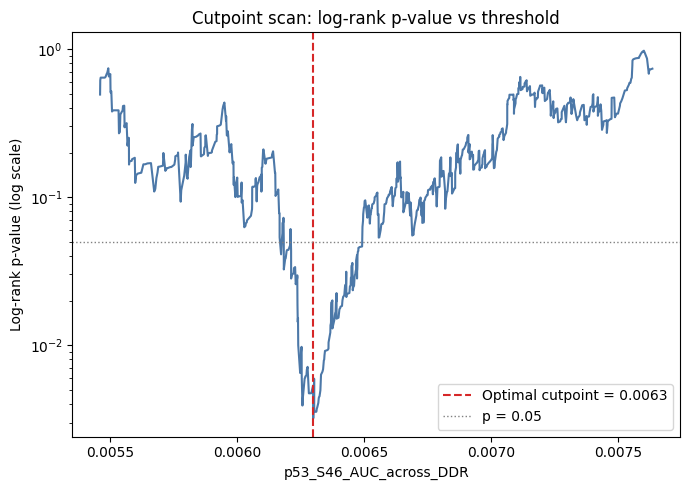

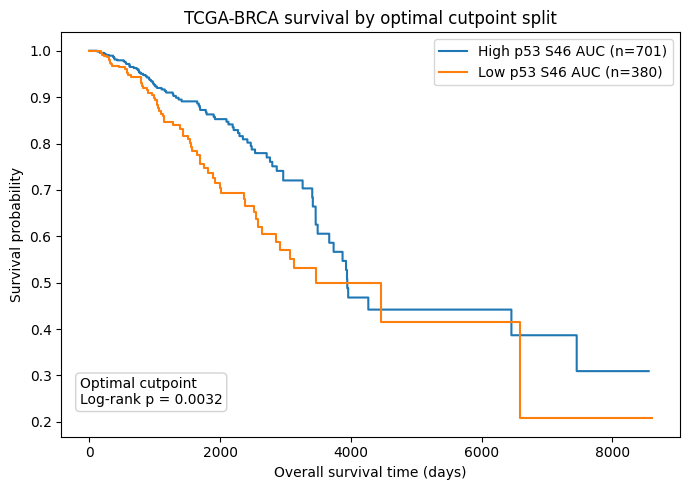

Saved cutpoint scan figure to: figures/q1_p53_ode_tcga_cutpoint_scan.png
Saved optimal cutpoint KM figure to: figures/q1_p53_ode_tcga_km_optimal_cutpoint.png


In [7]:
# Minimum p-value cutpoint diagnostic, saved as two separate report figures:
#   (1) the log-rank p-value at every candidate threshold (the cutpoint scan), and
#   (2) the Kaplan-Meier curves for the resulting optimal high/low split.

# Cutpoint scan: log-rank p-value vs threshold
plt.figure(figsize=(7, 5))
plt.plot(cutpoint_scan["threshold"], cutpoint_scan["p_value"], color="#4c78a8")
plt.axvline(optimal_threshold, color="#d62728", linestyle="--", linewidth=1.5,
            label=f"Optimal cutpoint = {optimal_threshold:.3g}")
plt.axhline(0.05, color="gray", linestyle=":", linewidth=1, label="p = 0.05")
plt.yscale("log")
plt.xlabel(main_p53_feature)
plt.ylabel("Log-rank p-value (log scale)")
plt.title("Cutpoint scan: log-rank p-value vs threshold")
plt.legend()
plt.tight_layout()
cutpoint_scan_path = km_figure_path.with_name("q1_p53_ode_tcga_cutpoint_scan.png")
plt.savefig(cutpoint_scan_path, dpi=200)
plt.show()

# Kaplan-Meier by optimal cutpoint split
plt.figure(figsize=(7, 5))
ax = plt.gca()
kmf_opt = KaplanMeierFitter()
for group_name, group_data in survival_data.groupby("p53_optimal_cut_group"):
    kmf_opt.fit(
        group_data["overall_survival_time"],
        event_observed=group_data["overall_survival_event"],
        label=f"{group_name} (n={len(group_data)})",
    )
    kmf_opt.plot_survival_function(ci_show=False, ax=ax)
plt.xlabel("Overall survival time (days)")
plt.ylabel("Survival probability")
plt.title("TCGA-BRCA survival by optimal cutpoint split")
plt.text(
    0.03, 0.08,
    f"Optimal cutpoint\nLog-rank p = {optimal_logrank.p_value:.3g}",
    transform=ax.transAxes,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "lightgray"},
)
plt.tight_layout()
optimal_km_path = km_figure_path.with_name("q1_p53_ode_tcga_km_optimal_cutpoint.png")
plt.savefig(optimal_km_path, dpi=200)
plt.show()

print("Saved cutpoint scan figure to:", cutpoint_scan_path.relative_to(project_root))
print("Saved optimal cutpoint KM figure to:", optimal_km_path.relative_to(project_root))

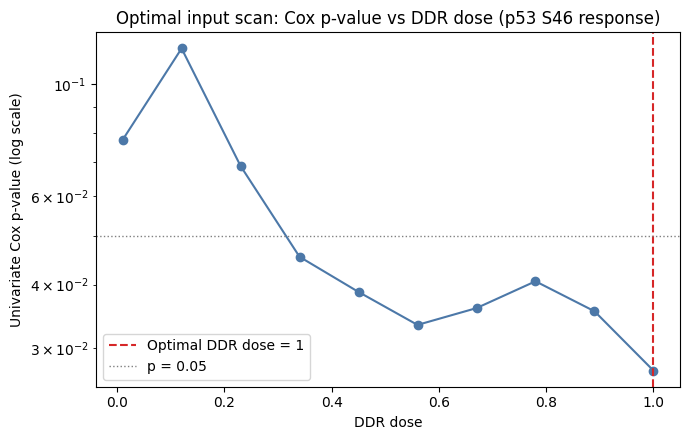

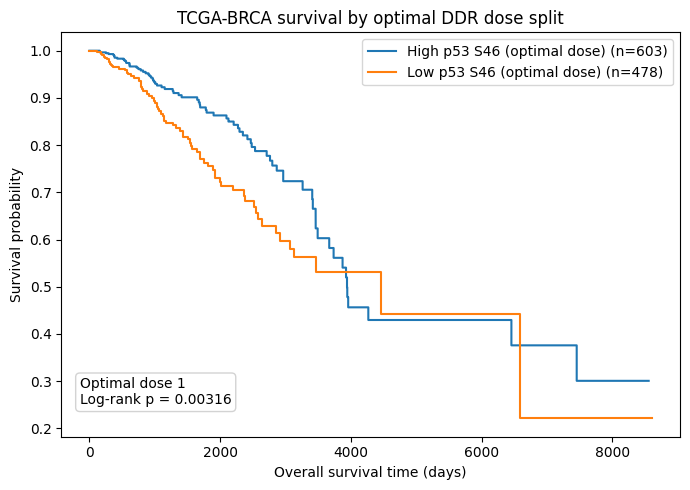

Saved optimal dose scan figure to: figures/q1_p53_ode_tcga_optimal_dose_scan.png
Saved optimal dose KM figure to: figures/q1_p53_ode_tcga_km_optimal_dose.png


In [8]:
# Optimal input diagnostic, saved as two report figures: the univariate Cox p-value at each
# DDR dose (the dose scan), and the Kaplan-Meier curves for the optimal dose after the cutpoint split.
plt.figure(figsize=(7, 4.5))
plt.plot(dose_scan["ddr_dose"], dose_scan["p_value"], marker="o", color="#4c78a8")
plt.axvline(optimal_dose, color="#d62728", linestyle="--", linewidth=1.5,
            label=f"Optimal DDR dose = {optimal_dose:.3g}")
plt.axhline(0.05, color="gray", linestyle=":", linewidth=1, label="p = 0.05")
plt.yscale("log")
plt.xlabel("DDR dose")
plt.ylabel("Univariate Cox p-value (log scale)")
plt.title("Optimal input scan: Cox p-value vs DDR dose (p53 S46 response)")
plt.legend()
plt.tight_layout()
optimal_dose_scan_path = km_figure_path.with_name("q1_p53_ode_tcga_optimal_dose_scan.png")
plt.savefig(optimal_dose_scan_path, dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
ax = plt.gca()
kmf_dose = KaplanMeierFitter()
for group_name, group_data in survival_data.groupby("p53_optimal_dose_group"):
    kmf_dose.fit(
        group_data["overall_survival_time"],
        event_observed=group_data["overall_survival_event"],
        label=f"{group_name} (n={len(group_data)})",
    )
    kmf_dose.plot_survival_function(ci_show=False, ax=ax)
plt.xlabel("Overall survival time (days)")
plt.ylabel("Survival probability")
plt.title("TCGA-BRCA survival by optimal DDR dose split")
plt.text(
    0.03, 0.08,
    f"Optimal dose {optimal_dose:.3g}\nLog-rank p = {optimal_dose_logrank.p_value:.3g}",
    transform=ax.transAxes,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "lightgray"},
)
plt.tight_layout()
optimal_dose_km_path = km_figure_path.with_name("q1_p53_ode_tcga_km_optimal_dose.png")
plt.savefig(optimal_dose_km_path, dpi=200)
plt.show()
print("Saved optimal dose scan figure to:", optimal_dose_scan_path.relative_to(project_root))
print("Saved optimal dose KM figure to:", optimal_dose_km_path.relative_to(project_root))

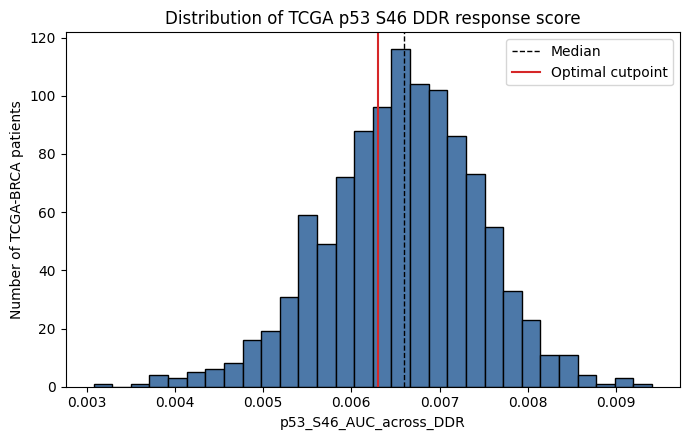

Saved feature distribution figure to: figures/q1_p53_ode_tcga_feature_distribution.png


In [9]:
plt.figure(figsize=(7, 4.5))
plt.hist(survival_data[main_p53_feature].dropna(), bins=30, edgecolor="black", color="#4c78a8")
plt.axvline(median_score, color="black", linestyle="--", linewidth=1, label="Median")
plt.axvline(optimal_threshold, color="#d62728", linestyle="-", linewidth=1.5, label="Optimal cutpoint")
plt.xlabel(main_p53_feature)
plt.ylabel("Number of TCGA-BRCA patients")
plt.title("Distribution of TCGA p53 S46 DDR response score")
plt.legend()
plt.tight_layout()
plt.savefig(distribution_figure_path, dpi=200)
plt.show()
print("Saved feature distribution figure to:", distribution_figure_path.relative_to(project_root))

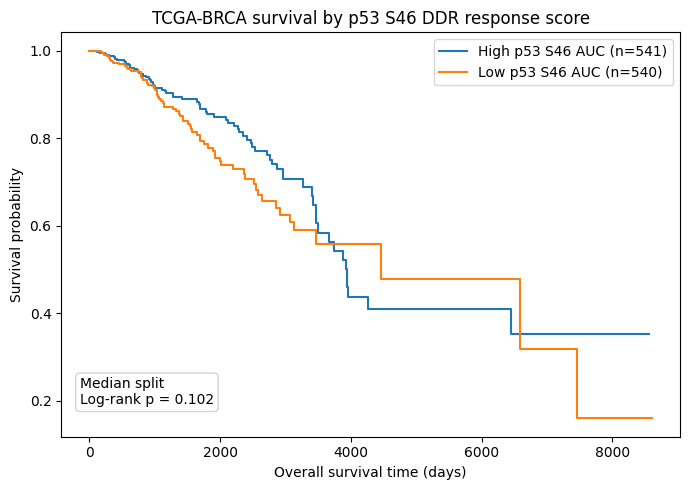

Saved Q1 KM figure to: figures/q1_p53_ode_tcga_km.png


In [10]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(7, 5))
for group_name, group_data in survival_data.groupby("p53_main_feature_group"):
    kmf.fit(
        group_data["overall_survival_time"],
        event_observed=group_data["overall_survival_event"],
        label=f"{group_name} (n={len(group_data)})",
    )
    kmf.plot_survival_function(ci_show=False)

plt.xlabel("Overall survival time (days)")
plt.ylabel("Survival probability")
plt.title("TCGA-BRCA survival by p53 S46 DDR response score")
plt.text(
    0.03,
    0.08,
    f"Median split\nLog-rank p = {logrank.p_value:.3g}",
    transform=plt.gca().transAxes,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "lightgray"},
)
plt.tight_layout()
plt.savefig(km_figure_path, dpi=200)
plt.show()
print("Saved Q1 KM figure to:", km_figure_path.relative_to(project_root))

## Q1 Interpretation

Use the saved Cox and Kaplan-Meier outputs to report whether the pre-specified p53 S46 AUC feature is associated with TCGA-BRCA overall survival.

This is a prognostic analysis. TCGA-BRCA does not directly measure doxorubicin response, so the result should not be described as evidence of chemotherapy sensitivity. The ODE model is adapted from the course template and depends on that model's biological assumptions.

Two high/low splits are reported: a median split and an optimal cutpoint split. The optimal cutpoint is the threshold that maximises log-rank separation, so its p-value is optimistic and should be read as an exploratory descriptive split rather than as an independent test. The continuous Cox model remains the primary survival analysis, and the cutpoint scan chart shows how sensitive the split is to the chosen threshold.

The optimal input scan adds the course's two-stage dose-then-cutpoint selection: it picks the DDR dose whose p53 S46 response is most prognostic and then splits on that response. Both the dose and the threshold are chosen to maximise separation, so this result is doubly data driven and is reported only as an exploratory sensitivity check alongside the pre-specified feature.